# Further characterisation of event types

**Characteristics explored in this notebook:**


**1. Prevalent clusters across stations**  
The percentage of each event type at each tide gauge station was calculated to identify the prevalent event types.

**2. Yearly count of events per cluster**  
Peaks within a cluster that occurred within ±2 days of each other were grouped as a single event, accounting for the possibility that the event impacted different stations at different times. Each unique group of peaks was then counted as **one event**, regardless of how many stations recorded it.

**3. Correlation with North Atlantic Oscillation (NAO) index**  
Correlation between the **mean yearly NAO index** and the **annual count of storm surge events** was calculated to explore atmospheric influence on surge activity.

**4. Cumulative intensity of an event**  
The intensity of a storm surge was determined by integrating sea level values that exceeded the 99th percentile over the event’s duration:
$$
I = \int_{t_i}^{t_f} \mathrm{NTR}_{\text{above}}(t) \, dt
$$

**5. Tide–surge phase difference**  
- Surge peaks were identified from time series data.  
- The **phase difference** between each extracted surge peak and the nearest high tide was calculated as:
$$
\varphi = t_{\text{peak surge}} - t_{\text{high tide}}
$$

<br>

> More details can be found in:  
> Pupić Vurilj, M. et al. *Storm surge hydrographs from historical observations of sea level along the Dutch North Sea coast.*  
> **Nat Hazards (2025).**  
> [https://doi.org/10.1007/s11069-025-07351-8](https://doi.org/10.1007/s11069-025-07351-8)

<br>

**Data to be loaded:**
- Non-tidal residual (NTR) data are stored as `.pkl` files, each containing a `pandas.Series` with a datetime index.
- High tide data are also stored as `.pkl` files, each containing a `pandas.Series` with a datetime index.
- Station metadata is provided in a `stations_info.csv` file, which includes station name, longitude, and latitude, 70th percentile threshold, and 99th percentile threshold.
- `extremes_NTR.pkl`, which contains a list of `pandas.DataFrame` objects, each representing detected storm surge events for a station (using 70th percentile method). Each dataframe has:
     - **Index**: Timestamps of event maxima (datetime index)  
     - **Columns**:
       - `max`: surge maximum of the event  
       - `duration`: event duration in hours  
       - `start`: datetime of the event start  
       - `end`: datetime of the event end
- `event_types.h5` that contains event types and associated hydrographs (event_types (dict) structured by type -> station -> index -> np.array)


## Load data

In [1]:
import pandas as pd

# Load station info (names,lon,lat)
stations = pd.read_csv("inputs/stations_info.csv")
stations

,station,lon,lat,p70,p99
0,Huibertgat,6.398433,53.573748,0.095109,0.900051
1,Schiermonnikoog,6.202908,53.468935,0.093707,1.000464
2,Eemshaven,6.828392,53.448699,0.096513,1.062970
3,Nes,5.758907,53.429936,0.092642,1.003521
4,Lauwersoog,6.196952,53.408684,0.093626,1.033275
5,West_Terschelling,5.220026,53.363043,0.085239,0.879679
6,Vlieland_Haven,5.091456,53.296125,0.081488,0.851187
7,Harlingen,5.409342,53.175632,0.093082,1.032932
8,Oudeschild,4.850192,53.038833,0.086672,0.878051
9,Den_Helder,4.744990,52.964357,0.085310,0.830807


In [3]:
import pickle

import h5py

# Load non-tidal residual data per station in a list
NTR = []
high_tides = []
for i in range(len(stations)):
    ntr_element = pd.read_pickle(f"inputs/NTR/ntr_{i}.pkl")
    high_tide_element = pd.read_pickle(
        f"inputs/high_water_tide_detrended/high_water_tide_{i}.pkl"
    )
    # Append loaded data to lists
    NTR.append(ntr_element)
    high_tides.append(high_tide_element)

# Load POT events for each station (lists) using 70th percentile
with open("inputs/extremes_NTR.pkl", "rb") as f:
    globals()["extremes_NTR"] = pickle.load(f)

# Load event_types
event_types = {}
with h5py.File("inputs/event_types.h5", "r") as f:
    # Iterate over each cluster group
    for cluster_name in f.keys():
        cluster_group = f[cluster_name]
        # Create a dictionary for this cluster
        cluster_data = {}
        # Iterate over each station in the cluster
        for station_name in cluster_group.keys():
            station_group = cluster_group[station_name]
            # Create a dictionary for the station containing its time series directly
            station_data = {}
            # Iterate over each time series in the station group (series_0, series_1, ...)
            for series_name in station_group.keys():
                # Retrieve the time series data
                hydrograph = station_group[series_name][:]
                # Add the time series directly to the station data
                station_data[series_name] = hydrograph
            # Add the station data to the cluster data
            cluster_data[station_name] = station_data
        # Add the cluster data to the main loaded data dictionary
        event_types[cluster_name] = cluster_data

## 1. Prevalent clusters across stations

In [4]:
from utils.characterisation import extract_top_event_types

top_event_types, unique_top_types = extract_top_event_types(event_types)

prevalent_types = {
    etype: stations
    for etype, stations in event_types.items()
    if etype in unique_top_types
}

# Print summary
for station, types in top_event_types.items():
    print(f"{station}: Top event types: {types}")

Brouwershavensche_Gat_08: Top event types: ['type_13']
Cadzand: Top event types: ['type_1']
Den_Helder: Top event types: ['type_1']
Eemshaven: Top event types: ['type_1']
Harlingen: Top event types: ['type_1']
Hoek_van_Holland: Top event types: ['type_3']
Huibertgat: Top event types: ['type_1']
Lauwersoog: Top event types: ['type_1']
Nes: Top event types: ['type_1', 'type_2']
Oudeschild: Top event types: ['type_1', 'type_23', 'type_4', 'type_5', 'type_6', 'type_7']
Petten_Zuid: Top event types: ['type_4']
Scheveningen: Top event types: ['type_2', 'type_8']
Schiermonnikoog: Top event types: ['type_1']
Vlieland_Haven: Top event types: ['type_2', 'type_5']
West_Terschelling: Top event types: ['type_3', 'type_4']
Westkapelle: Top event types: ['type_1']


## 2. Yearly count of events per cluster

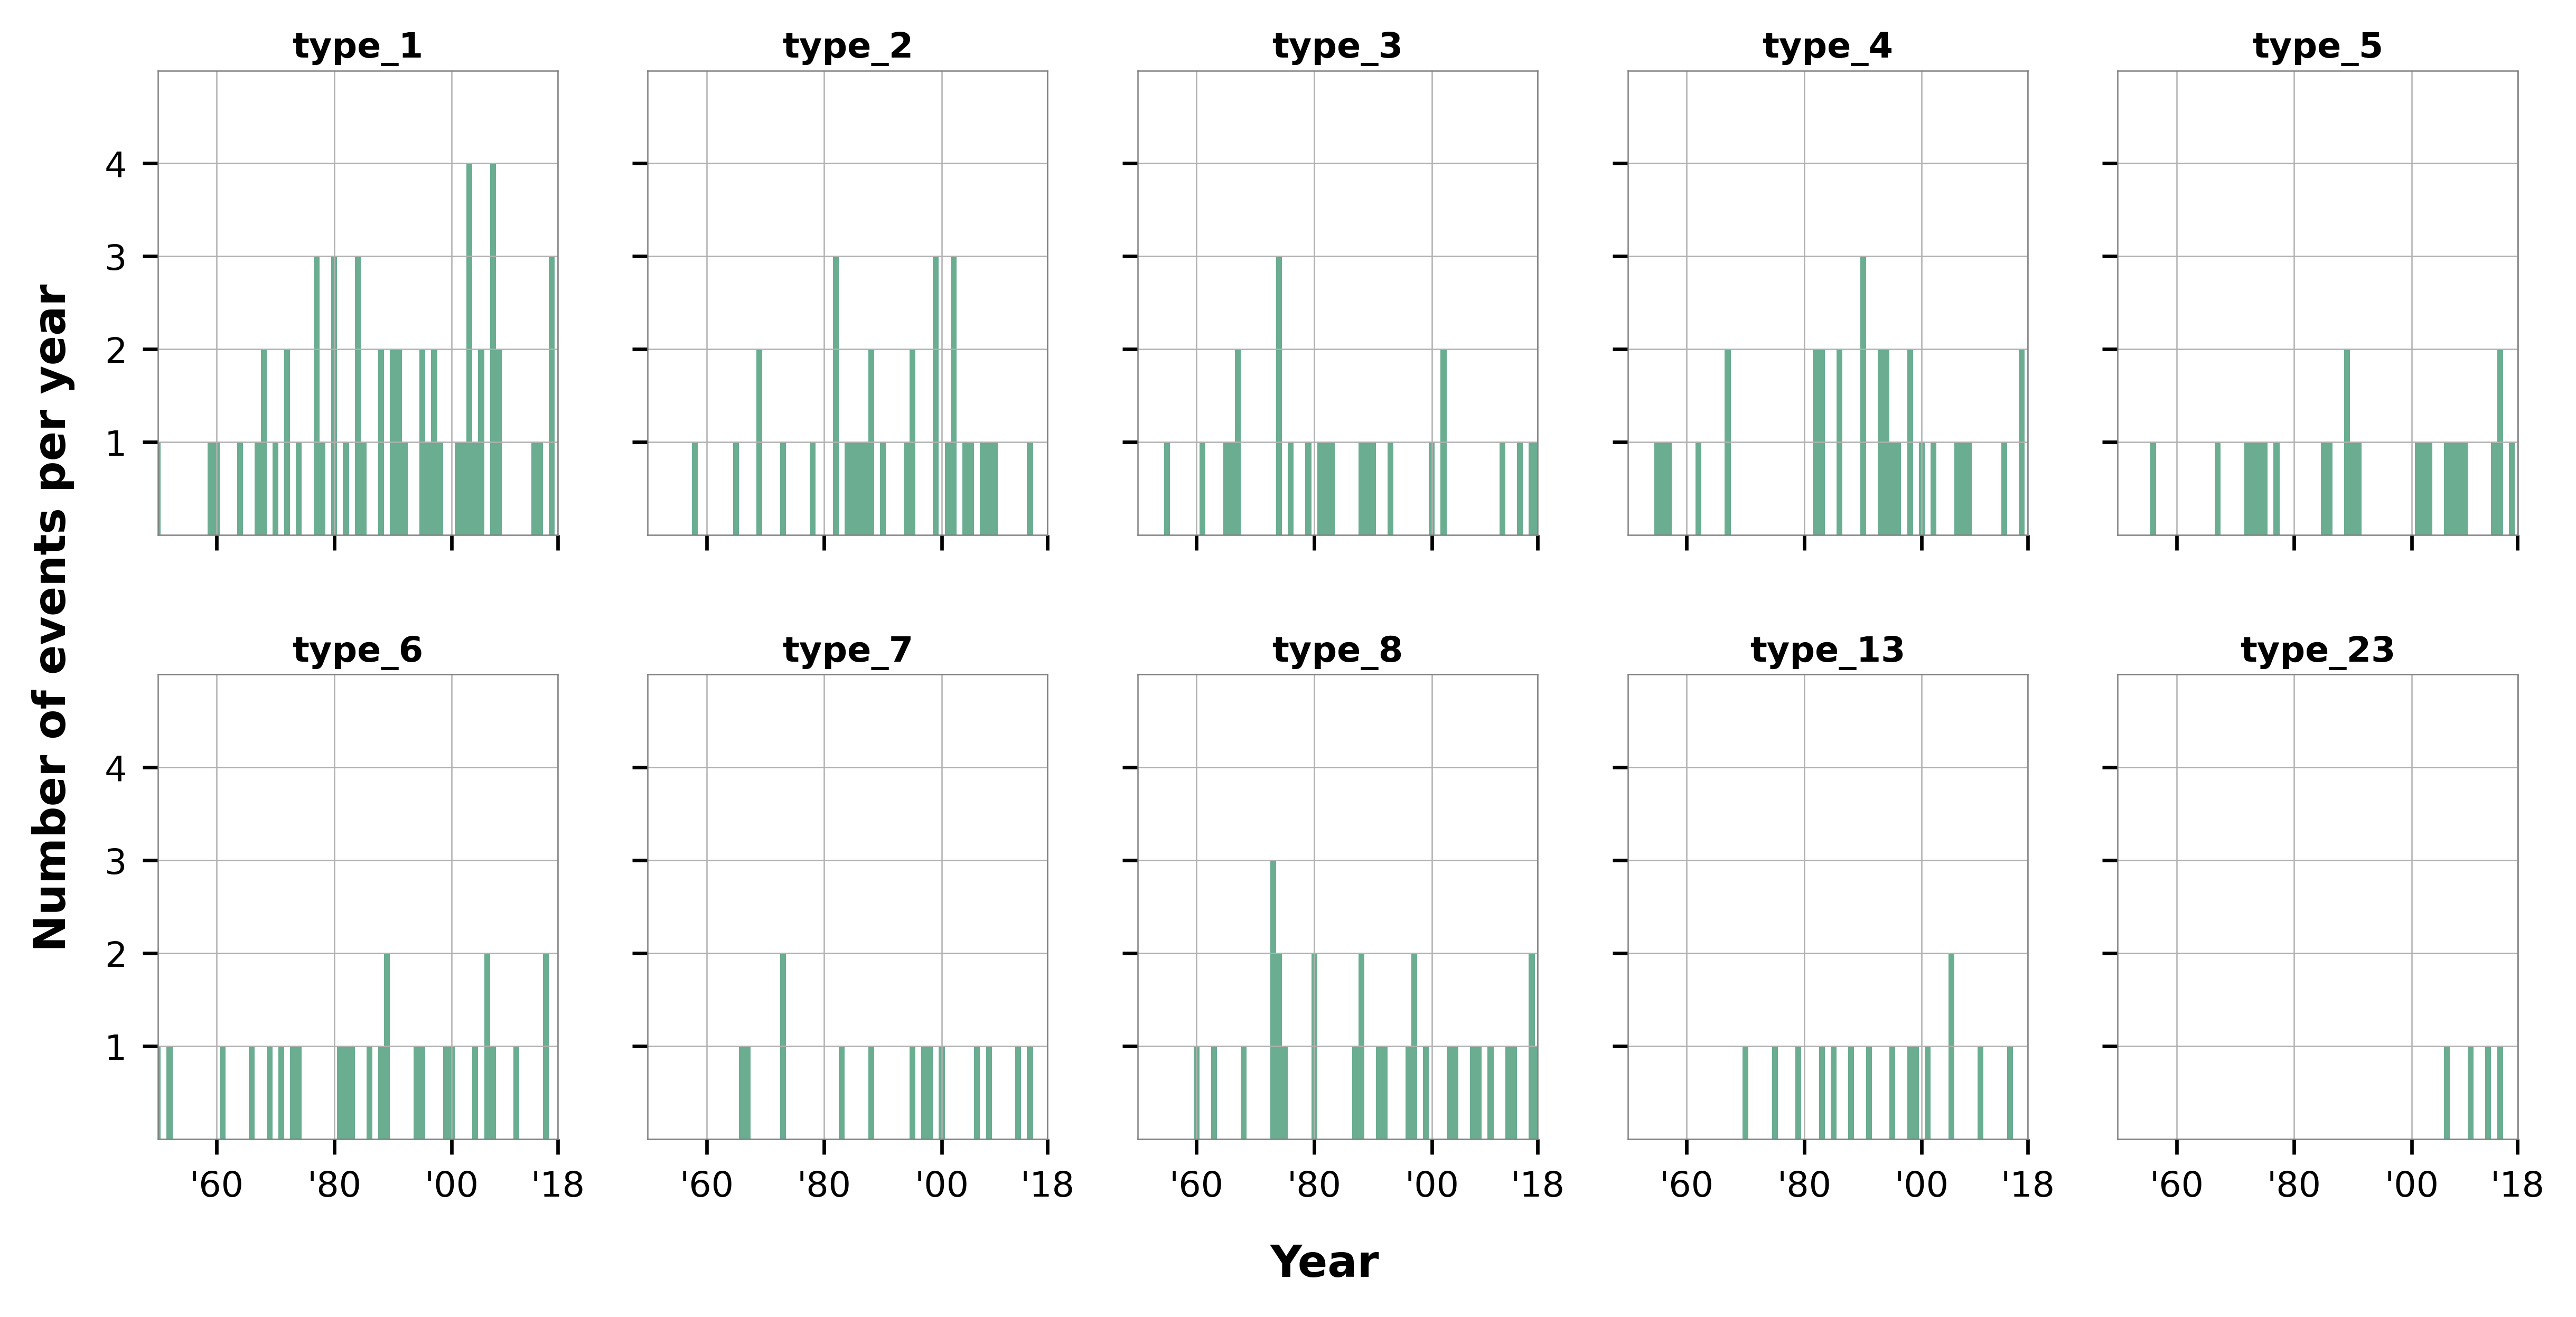

In [6]:
from utils.characterisation import (
    extract_event_type_datetimes,
    plot_yearly_event_counts,
)

# Extract datetime information for each event type based on the event maxima index
# and compute unique event dates and yearly event counts (grouped by ±2 days)

datetime_clusters, unique_dates, unique_yearly_count = extract_event_type_datetimes(
    event_types=prevalent_types,  # or event_types
    extremes_NTR=extremes_NTR,
)

# Plot the result
plot_yearly_event_counts(
    prevalent_types,
    unique_yearly_count,
    num_rows=2,
    num_cols=5,
)

## 3. Correlation with North Atlantic Oscillation (NAO) index

Pearson:  0.315 (p=0.0107)
Spearman: 0.334 (p=0.0065)
Kendall:  0.236 (p=0.0084)


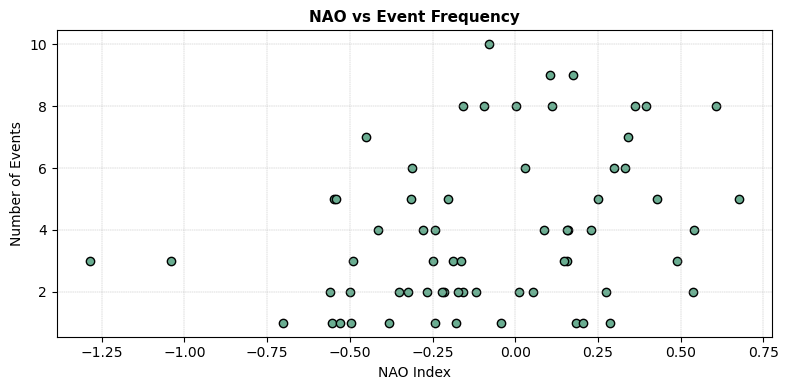

In [7]:
from utils.characterisation import (
    aggregate_cluster_events,
    compute_annual_nao_means,
    compute_correlations,
    download_nao_index,
    filter_years,
    plot_scatter_nao_vs_events,
)

# Step 1: Get and parse NAO data
nao_df = download_nao_index()

# Step 2: Compute yearly NAO index
nao_index = compute_annual_nao_means(nao_df)

# Step 3: Filter by year
nao_index_filtered = filter_years(nao_index, 1950, 2017)

# Step 4: Aggregate your event data
total_events_per_year = aggregate_cluster_events(unique_yearly_count)
total_events_per_year_filtered = filter_years(total_events_per_year, 1950, 2017)

# Step 5: Correlate
compute_correlations(total_events_per_year_filtered, nao_index_filtered)

# Plot
plot_scatter_nao_vs_events(total_events_per_year_filtered, nao_index_filtered)

## 4. Cumulative Intensity of an event

In [8]:
from utils.characterisation import (
    compute_cumulative_intensities_types,
    extract_all_event_timeseries_and_high_tides,
)

# Concatenate all POT70 event timeseries and extract the high tides per each such event
NTR_timeseries, high_tides_timeseries = extract_all_event_timeseries_and_high_tides(
    NTR, high_tides, extremes_NTR
)

# Compute cumulative intensities for each event in each event type
cumulative_intensity = compute_cumulative_intensities_types(
    event_types, NTR_timeseries, stations
)

In [9]:
# Top 10 events
from utils.characterisation import get_top_events

top_10_events = get_top_events(cumulative_intensity, event_types, top_n=10)

print(f"{'Rank':<5} {'Intensity':<10} {'Type':<10} {'Station':<12} {'Key'}")
for rank, (intensity, event_type, station, key_str) in enumerate(top_10_events, 1):
    print(f"{rank:<5} {intensity:<10.2f} {event_type:<10} {station:<12} {key_str}")

Rank  Intensity  Type       Station      Key
1     120.45     type_30    Harlingen    21116
2     111.55     type_30    Eemshaven    5545
3     94.54      type_30    West_Terschelling 14202
4     93.39      type_30    Oudeschild   23554
5     88.72      type_9     Harlingen    19359
6     87.33      type_25    Eemshaven    5696
7     85.24      type_30    Brouwershavensche_Gat_08 38397
8     82.78      type_16    Nes          7437
9     82.66      type_16    Harlingen    20469
10    81.96      type_38    Eemshaven    5106


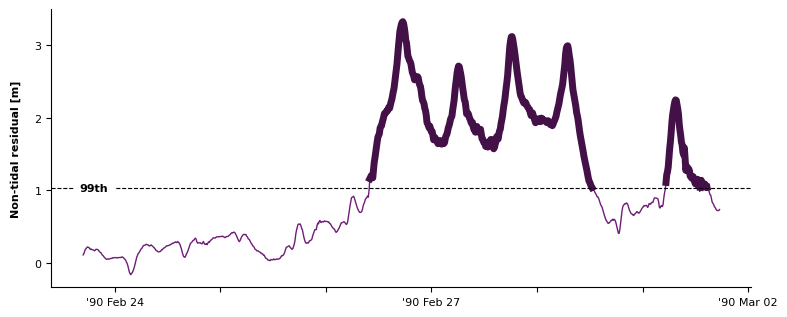

In [10]:
# Plot an event using the Key and Threshold
from utils.characterisation import plot_event_cumulative_intensity

threshold_99 = stations.loc[stations["station"] == "Harlingen", "p99"].values[0]

plot_event_cumulative_intensity(
    event_types, NTR_timeseries, threshold_99=threshold_99, key=21116
)

## 5. Tide–surge phase difference

In [11]:
from utils.characterisation import (
    extract_original_maxima_near_peaks,
    find_peaks_in_smoothed,
    # plot_all_events,
    smooth_signal,
)

# 1. Collect all keys from event_types to plot (limit if needed)
keys = []
for type_dict in event_types.values():
    for station_dict in type_dict.values():
        for key_str in station_dict.keys():
            keys.append(int(key_str))
keys = keys[:972]  # desired max (972 events in event_types)

# 2. Process all event time series for these keys
processed_events = []
for key in keys:
    series = NTR_timeseries[
        key
    ]  # we select only the events that went into clustering (MDA subset)

    # smooth
    smoothed, win_size, time_step_sec = smooth_signal(series, window_hours=12)

    # find peaks
    smoothed_peaks = find_peaks_in_smoothed(smoothed, series.index, time_step_sec)

    # find original maxima near peaks
    maxima = extract_original_maxima_near_peaks(
        series, smoothed_peaks, search_radius=win_size // 2
    )

    processed_events.append(
        {
            "key": key,
            "series": series,
            "smoothed": smoothed,
            "peaks": smoothed_peaks,
            "maxima": maxima,
        }
    )


# 3. Now you can use all maxima or any other result from processed_events
all_maxima = [event["maxima"] for event in processed_events]

# 4. Plot all processed events
# plot_all_events(processed_events)

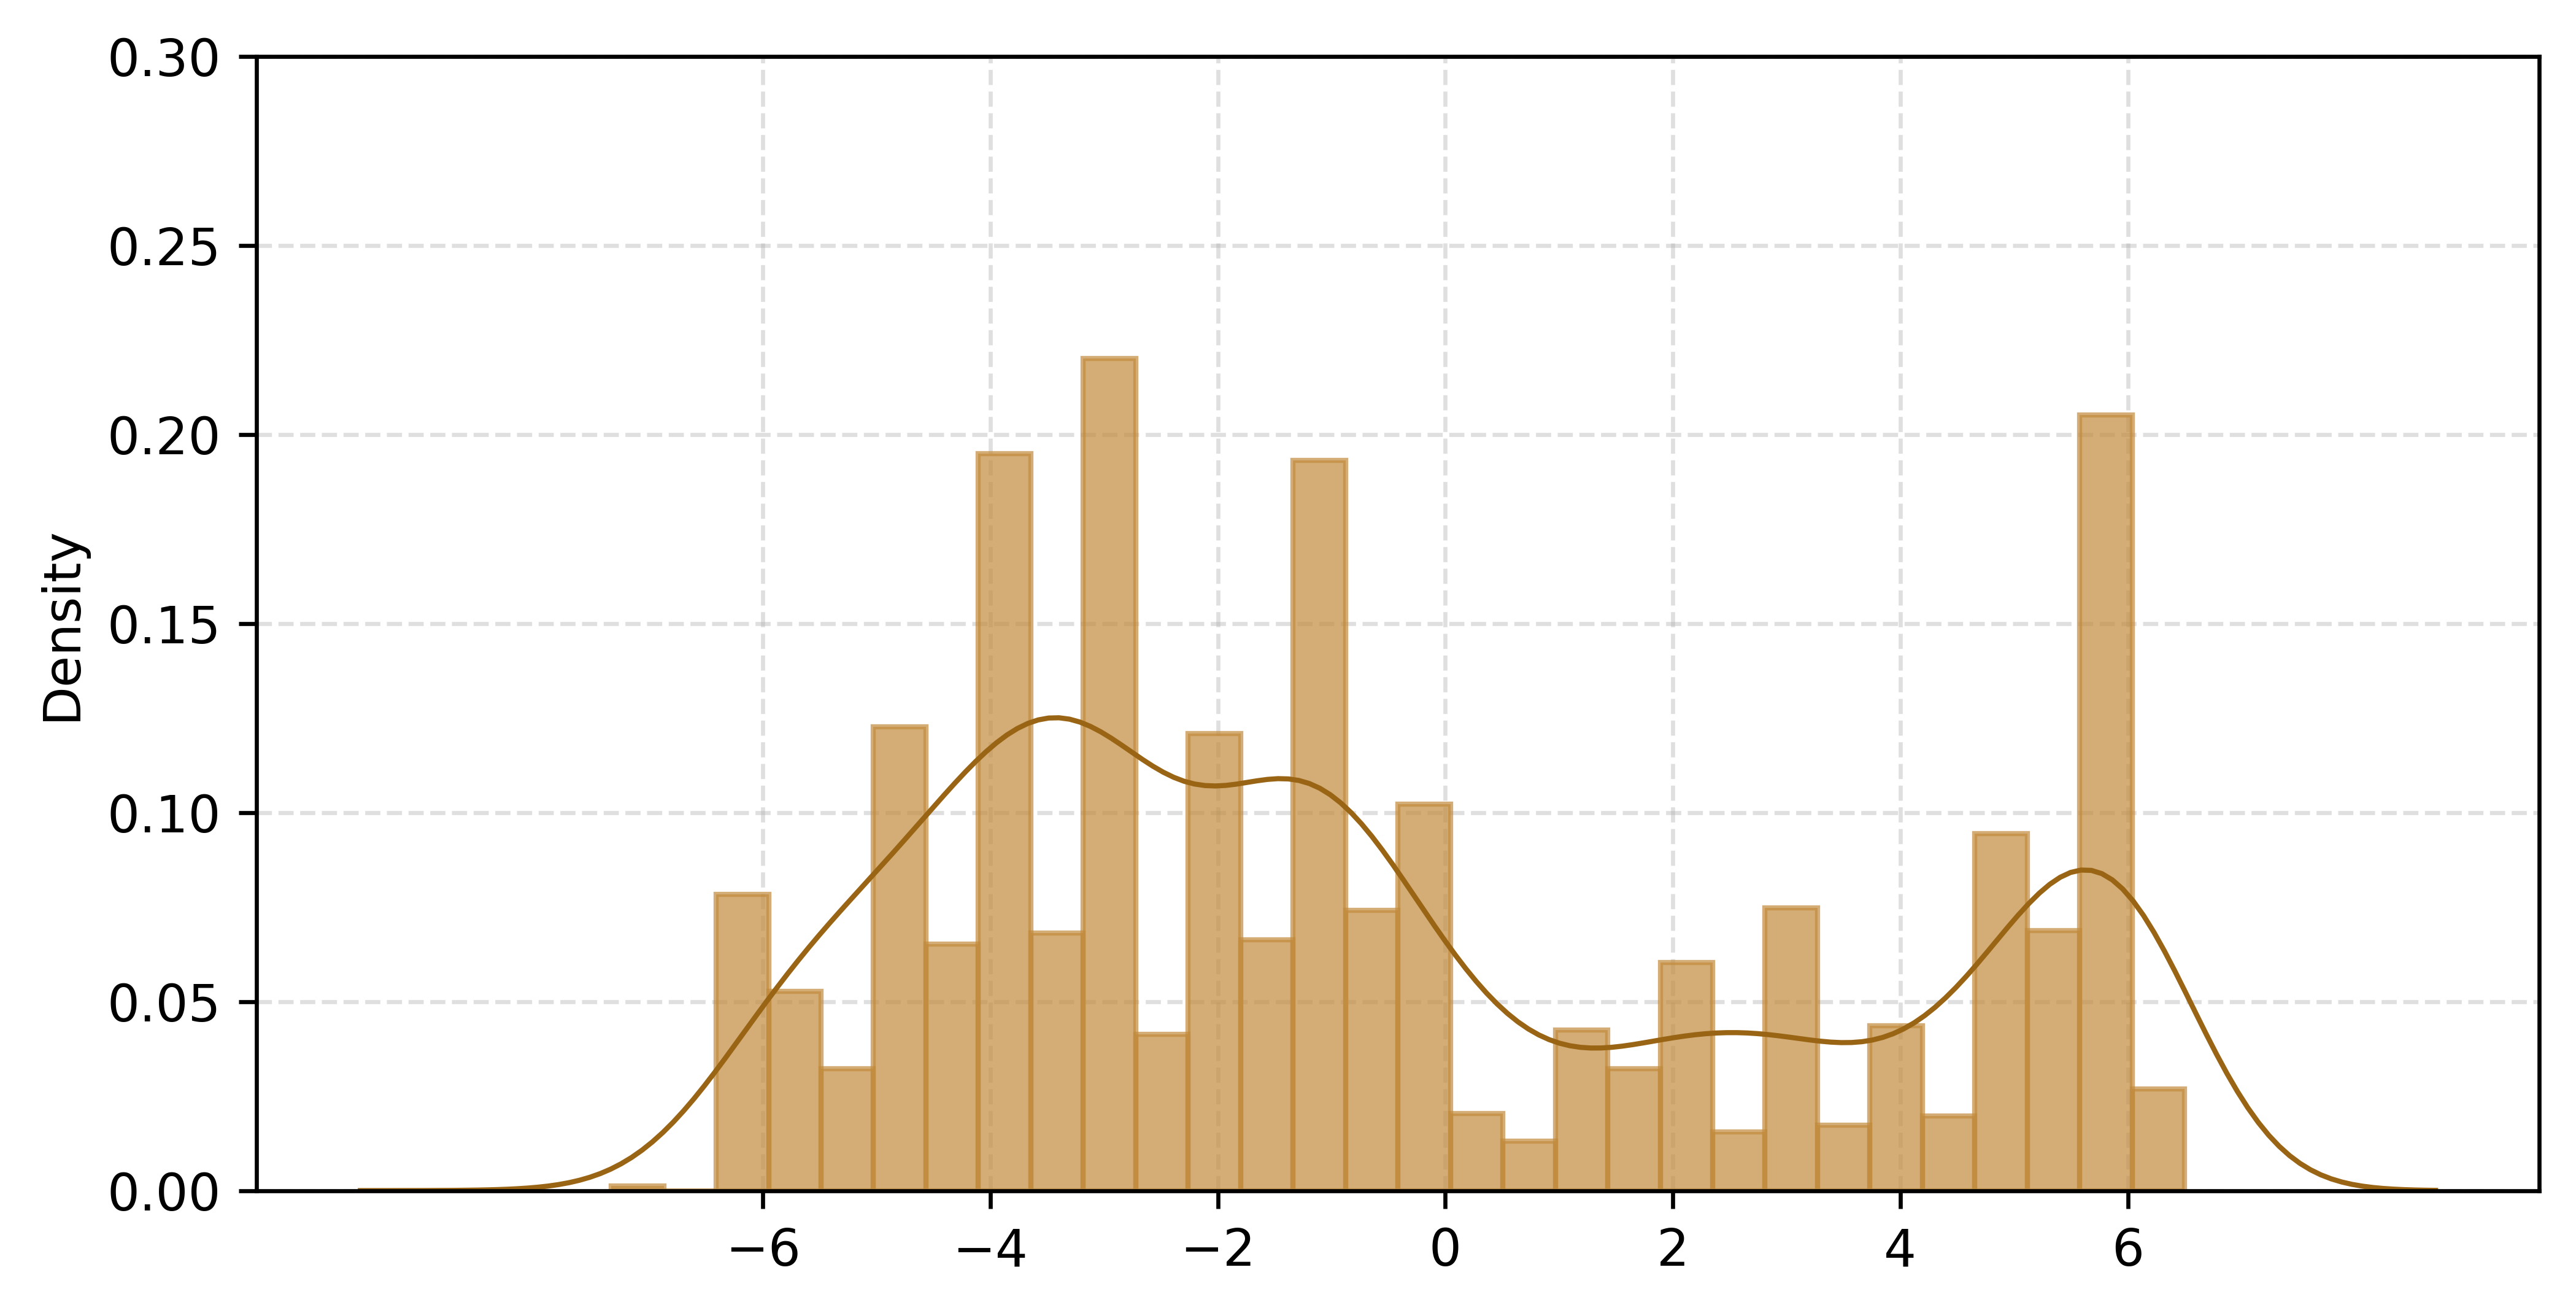

In [12]:
from utils.characterisation import find_nearest_high_tide, plot_time_diff_histogram

time_differences = []

for i, key in enumerate(keys):
    maxima_for_this_series = all_maxima[i]  # list of (time, value)
    high_tide_series = high_tides_timeseries[key]  # get high tide series for this key
    high_tide_times = pd.to_datetime(high_tide_series.index)

    for peak_time, peak_val in maxima_for_this_series:
        nearest_high_tide, time_diff = find_nearest_high_tide(
            peak_time, high_tide_times
        )
        time_differences.append(time_diff)

# Plot histogram
plot_time_diff_histogram(time_differences)